<div style="
  background: linear-gradient(to right, #FF8C00, #FF4500);
  padding: 15px;
  border-radius: 20px;
  text-align: center;
  font-size: 36px;
  font-family: 'Press Start 2P', cursive;
  color: white;
  text-shadow: 0px 0px 15px #FFA500, 0px 0px 25px #FF4500;
  box-shadow: 0px 0px 20px rgba(255, 69, 0, 0.7);
  display: flex;
  align-items: center;
  justify-content: center;
  gap: 10px;
">
🖼️✨ Image Processing with ROI Masking! ✨🖼️
</div>


<div style="
  background: linear-gradient(to right, #00BFFF, #1E90FF);
  padding: 15px;
  border-radius: 20px;
  text-align: center;
  font-size: 36px;
  font-family: 'Press Start 2P', cursive;
  color: white;
  text-shadow: 0px 0px 15px #87CEFA, 0px 0px 25px #1E90FF;
  box-shadow: 0px 0px 20px rgba(30, 144, 255, 0.7);
  display: flex;
  align-items: center;
  justify-content: center;
  gap: 10px;
">
🎭📐 Define and Apply ROI with Precision! 📐🎭
</div>

<div style="
  background: linear-gradient(to right, #32CD32, #228B22);
  padding: 15px;
  border-radius: 20px;
  text-align: center;
  font-size: 36px;
  font-family: 'Press Start 2P', cursive;
  color: white;
  text-shadow: 0px 0px 15px #98FB98, 0px 0px 25px #32CD32;
  box-shadow: 0px 0px 20px rgba(50, 205, 50, 0.7);
  display: flex;
  align-items: center;
  justify-content: center;
  gap: 10px;
">
🔍🎯 Focus on What Matters Most! 🎯🔍
</div>

✅ Image saved: output\original.png


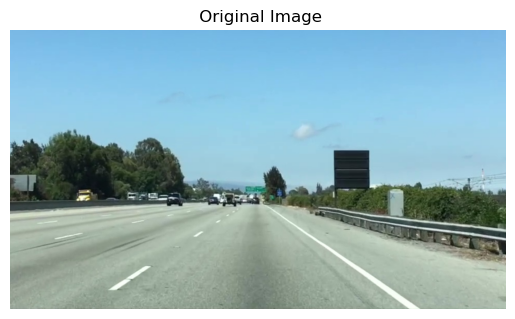

✅ Image saved: output\grayscale.png


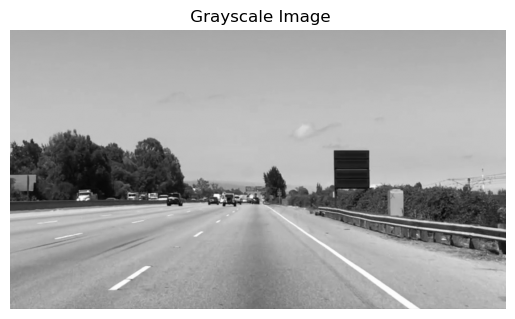

✅ Image saved: output\masked.png


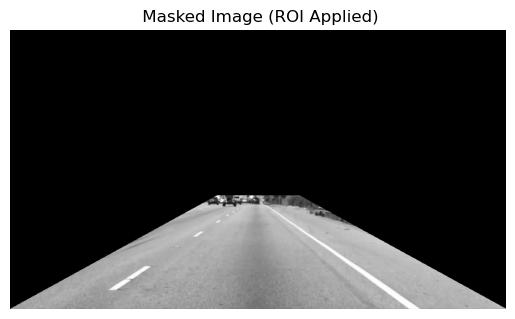


🎉 Image processing completed successfully!


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 📂 Output directory for saving processed images
OUTPUT_FOLDER = "output"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)  # Ensure the folder exists before saving files

def load_image(image_path):
    """
    📥 Load an image from the specified path and convert it to RGB format.
    
    OpenCV loads images in BGR format by default, but Matplotlib expects RGB.
    If the file is not found, an error message is displayed.
    
    Parameters:
        image_path (str): The file path of the image to load.

    Returns:
        np.array: RGB image array or None if loading fails.
    """
    image = cv2.imread(image_path)

    if image is None:  # 🛑 Prevents the script from crashing if the file is missing
        print(f"❌ Error: Unable to load image from '{image_path}'")
        return None

    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for proper visualization

def display_and_save(image, title, filename):
    """
    📸 Display an image with a title and save it to the output folder.

    Uses Matplotlib to display the image and saves it as a PNG file.

    Parameters:
        image (np.array): The image array to display.
        title (str): The title for the image.
        filename (str): The name of the file to save (without path).
    """
    plt.imshow(image, cmap='gray' if len(image.shape) == 2 else None)  # Convert to grayscale if needed
    plt.axis('off')  # Hide axis for better visualization
    plt.title(title)  # Set image title
    
    save_path = os.path.join(OUTPUT_FOLDER, filename)  # Full path to save
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.1)  # Save the image without extra whitespace
    print(f"✅ Image saved: {save_path}")  # Confirm save
    
    plt.show()  # Display the image

def apply_roi(image_gray):
    """
    📐 Define and apply a Region of Interest (ROI) mask to focus on a specific part of the image.

    The ROI is dynamically generated based on the image dimensions to ensure scalability.
    A polygon mask is applied to extract only the area of interest.

    Parameters:
        image_gray (np.array): The grayscale image.

    Returns:
        np.array: The masked image where only the selected region is visible.
    """
    height, width = image_gray.shape  # Get image dimensions

    # 🛠️ Define a triangular region covering the lower center of the image
    ROI = np.array([[
        (0, height),  # Bottom-left corner
        (width // 2 - 80, height // 2 + 50),  # Mid-left
        (width // 2 + 80, height // 2 + 50),  # Mid-right
        (width, height)  # Bottom-right corner
    ]], dtype=np.int32)

    # 🎭 Create a blank mask (same size as the grayscale image)
    mask = np.zeros_like(image_gray, dtype=np.uint8)

    # 🖌️ Fill the defined polygon area with white (255) to create a mask
    cv2.fillPoly(mask, ROI, 255)

    # 🔍 Apply the mask using bitwise AND operation (everything outside ROI is blacked out)
    masked_image = cv2.bitwise_and(image_gray, mask)
    return masked_image

# 🔥 Main Processing Pipeline
image_path = "image_lane_c.jpg"  # 🖼️ Path to the input image
image_color = load_image(image_path)  # Load and convert image

if image_color is not None:  # ✅ Only proceed if image loading was successful
    display_and_save(image_color, " Original Image", "original.png")  # Show and save the original image

    # 🎨 Convert to grayscale for processing
    image_gray = cv2.cvtColor(image_color, cv2.COLOR_RGB2GRAY)
    display_and_save(image_gray, " Grayscale Image", "grayscale.png")

    # 🎯 Apply Region of Interest (ROI) mask
    masked_image = apply_roi(image_gray)
    display_and_save(masked_image, " Masked Image (ROI Applied)", "masked.png")

    print("\n🎉 Image processing completed successfully!")

<div style="
  background: linear-gradient(to right, #8B4513, #D2691E);
  padding: 15px;
  border-radius: 20px;
  text-align: center;
  font-size: 36px;
  font-family: 'Press Start 2P', cursive;
  color: white;
  text-shadow: 0px 0px 15px #CD853F, 0px 0px 25px #8B4513;
  box-shadow: 0px 0px 20px rgba(139, 69, 19, 0.7);
  display: flex;
  align-items: center;
  justify-content: center;
  gap: 10px;
">
🎨🛠️ Enhance Image Detection with ROI! 🛠️🎨
</div>


<div style="
  background: linear-gradient(to right, #DC143C, #B22222);
  padding: 15px;
  border-radius: 20px;
  text-align: center;
  font-size: 36px;
  font-family: 'Press Start 2P', cursive;
  color: white;
  text-shadow: 0px 0px 15px #FF6347, 0px 0px 25px #B22222;
  box-shadow: 0px 0px 20px rgba(220, 20, 60, 0.7);
  display: flex;
  align-items: center;
  justify-content: center;
  gap: 10px;
">
📸🔲 Mask, Edit & Process with Ease! 🔲📸
</div>

<div style="
  background: linear-gradient(to right, #FFD700, #FF8C00);
  padding: 15px;
  border-radius: 20px;
  text-align: center;
  font-size: 36px;
  font-family: 'Press Start 2P', cursive;
  color: black;
  text-shadow: 0px 0px 15px #FFF176, 0px 0px 25px #FFD700;
  box-shadow: 0px 0px 20px rgba(255, 215, 0, 0.7);
  display: flex;
  align-items: center;
  justify-content: center;
  gap: 10px;
">
🎭🚀 ROI for Model Training & Computer Vision! 🚀🎭
</div>
